# Pricing European Options Using the Black-Scholes-Merton Pricing Formulas

Let $S_0$ be the current price of the underlying stock, $r$ the riskless interest rate, and $K$ the strike price. Further, let $T$ denote the time to maturity in years and $\sigma$ the volatility of the underlying stock. The price $c$ of a European call option is given by

$$ c = S_0 N(d_1) - Ke^{-rT} N(d_2) \tag{1} $$

and the price $p$ of a European put option is given by

$$ p = Ke^{-rT}N(-d_2) - S_0 N(-d_1) \tag{2} $$

where 

$$ d_1 = \frac{\ln(S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}} $$

and

$$ d_2 = \frac{\ln(S_0/K) + (r - \frac{\sigma^2}{2})T}{\sigma \sqrt{T}} = d_1 - \sigma \sqrt{T}. $$

$N$ denotes the cumulative distribution function of a standard normal variable. 

In [1]:
import numpy as np
from scipy.integrate import quad
from matplotlib.pylab import plt

The probability density function (PDF) of the standard normal variable is given by

$$ f(x) = \frac{1}{\sqrt{2\pi}} e^{\frac{-x^2}{2}} $$

and can be calculated using the following function:

In [2]:
'''
Calculates the value at x of the PDF of the standard normal variable.
'''

def snv_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

The cumulative distribution function (CDF) of the standard normal variable is therefore

$$ N(x) = \int_{-\infty}^{x} f(u) du = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x} e^{\frac{-u^2}{2}} du $$

and can be calculated as follows:

In [3]:
'''
Calculates the value at d of the CDF of the standard normal variable.
'''

def snv_cdf(d):
    return quad(lambda x: snv_pdf(x), -np.inf, d)[0] # quad function returns a 2-tuple (result, error)

The value of $d_1$ can be calculated as follows:

In [4]:
'''
Calculates d1 in the BSM model.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity (in years)

Returns : value of d1
'''

def calc_d1(S0, K, r, sigma, T):
    num = np.log(S0 / K) + (r + 0.5 * sigma**2) * T
    den = sigma * np.sqrt(T)

    return num / den

To calculate the price of a European call option:

In [5]:
'''
Calculates the BSM value of a European call option.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity

Returns : BSM value of a European call option
'''

def bsm_call(S0, K, r, sigma, T):
    d1 = calc_d1(S0, K, r, sigma, T)
    d2 = d1 - sigma * np.sqrt(T)

    return S0 * snv_cdf(d1) - K * np.exp(-r * T) * snv_cdf(d2)

Similarly, to calculate the price of a European put option:

In [6]:
'''
Calculates the BSM value of a European put option.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity

Returns : BSM value of a European put option
'''

def bsm_put(S0, K, r, sigma, T):
    d1 = calc_d1(S0, K, r, sigma, T)
    d2 = d1 - sigma * np.sqrt(T)

    return K * np.exp(-r * T) * snv_cdf(-d2) - S0 * snv_cdf(-d1)

## An Example

Consider the following parameters:

In [7]:
S0 = 49
K = 50
r = 0.05
sigma = 0.20
T = 0.3846

### Call option

Suppose this is a call option. Then, its value is given by:

In [8]:
call_value = bsm_call(S0, K, r, sigma, T)
print(f"The value of the call option is: {call_value: .2f}")

The value of the call option is:  2.40


The price of this European call option varies with the strike price as follows:

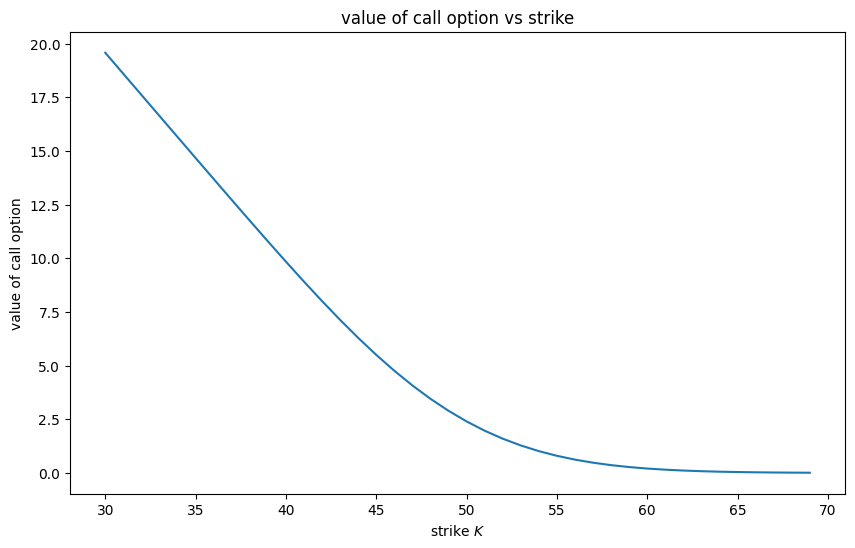

In [9]:
strike_values = np.array(range(30, 70))
call_values_strike = np.array([bsm_call(S0, strike_value, r, sigma, T) for strike_value in strike_values])

plt.figure(figsize=(10, 6))
plt.plot(strike_values, call_values_strike)
plt.xlabel('strike $K$')
plt.ylabel('value of call option')
plt.title('value of call option vs strike')
plt.show()

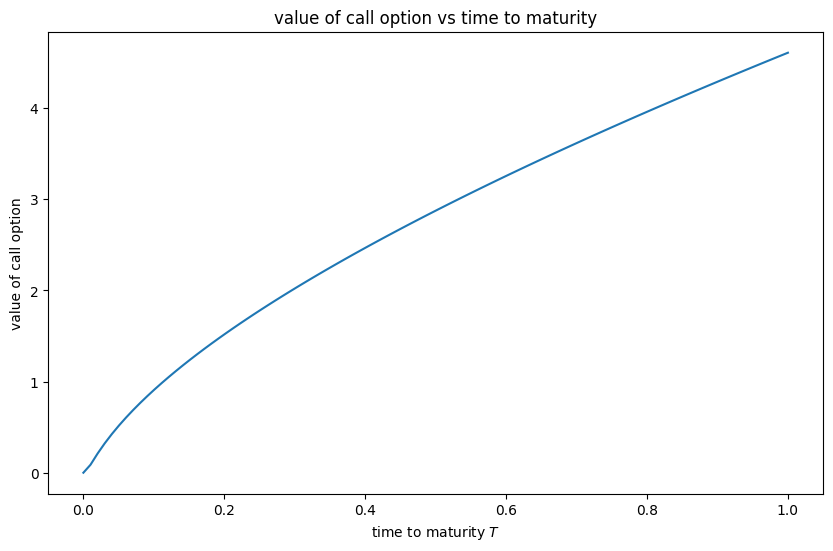

In [10]:
times = np.linspace(0.0001, 1, 100)
call_values_time = np.array([bsm_call(S0, K, r, sigma, time) for time in times])

plt.figure(figsize=(10, 6))
plt.plot(times, call_values_time)
plt.xlabel('time to maturity $T$')
plt.ylabel('value of call option')
plt.title('value of call option vs time to maturity')
plt.show()

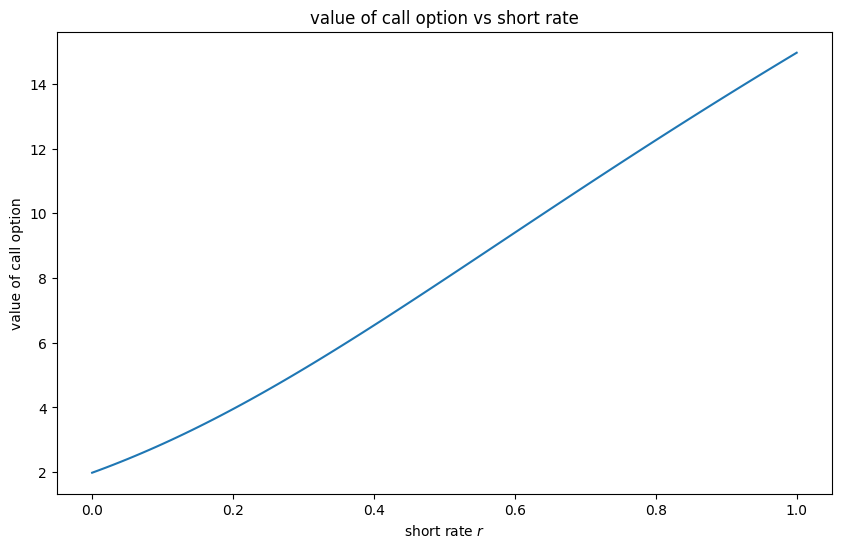

In [11]:
rates = np.linspace(0, 1, 100)
call_values_rate = np.array([bsm_call(S0, K, rate, sigma, T) for rate in rates])

plt.figure(figsize=(10, 6))
plt.plot(rates, call_values_rate)
plt.xlabel('short rate $r$')
plt.ylabel('value of call option')
plt.title('value of call option vs short rate')
plt.show()

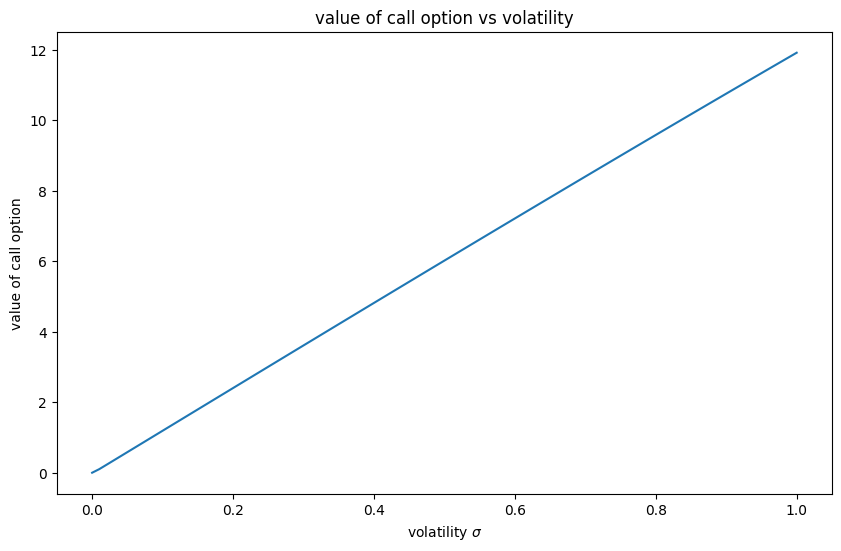

In [12]:
vols = np.linspace(0.0001, 1, 100)
call_values_vol = np.array([bsm_call(S0, K, r, vol, T) for vol in vols])

plt.figure(figsize=(10, 6))
plt.plot(vols, call_values_vol)
plt.xlabel('volatility $\\sigma$')
plt.ylabel('value of call option')
plt.title('value of call option vs volatility')
plt.show()

### Put option

Now suppose that the option is a put option.

In [13]:
put_value = bsm_put(S0, K, r, sigma, T)
print(f"The value of the put option is: {put_value: .2f}")

The value of the put option is:  2.45


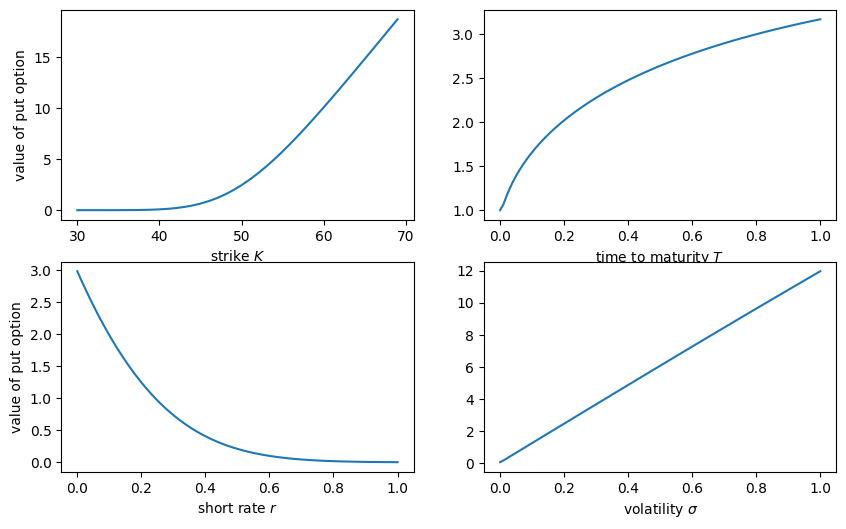

In [14]:
plt.figure(figsize=(10, 6))

plt.subplot(221)
kvalues = np.array(range(30, 70))
put_values_strike = np.array([bsm_put(S0, k, r, sigma, T) for k in kvalues])
plt.plot(kvalues, put_values_strike)
plt.xlabel('strike $K$')
plt.ylabel('value of put option')

plt.subplot(222)
tvalues = np.linspace(0.0001, 1, 100)
put_values_time = np.array([bsm_put(S0, K, r, sigma, t) for t in tvalues])
plt.plot(tvalues, put_values_time)
plt.xlabel('time to maturity $T$')

plt.subplot(223)
rvalues = np.linspace(0.0001, 1, 100)
put_values_r = np.array([bsm_put(S0, K, rate, sigma, T) for rate in rvalues])
plt.plot(rvalues, put_values_r)
plt.xlabel('short rate $r$')
plt.ylabel('value of put option')

plt.subplot(224)
vvalues = np.linspace(0.0001, 1, 100)
put_values_v = np.array([bsm_put(S0, K, r, v, T) for v in vvalues])
plt.plot(vvalues, put_values_v)
plt.xlabel('volatility $\\sigma$')

plt.show()

## Greeks in the BSM Model

### Delta

The delta ($\Delta$) of an option is the rate of change of the option price with respect to the price of the underlying asset:

$$ \Delta = \frac{\partial c}{\partial S}. $$

Hence, delta of a European call option on a non-dividend-paying stock according to the BSM model is

$$ \Delta(\text{call}) = N(d_1) $$

and that of a European put option is

$$ \Delta(\text{put}) = N(d_1) - 1.$$

In [15]:
'''
Calculates the delta of a European option.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity
opt_type: option type, call or put

Returns : Delta of a European option
'''

def bsm_delta(S0, K, r, sigma, T, opt_type="call"):
    d1 = calc_d1(S0, K, r, sigma, T)
    if opt_type == "put":
        return snv_cdf(d1) - 1
    return snv_cdf(d1)

Using the earlier example, we get:

In [16]:
delta = bsm_delta(S0, K, r, sigma, T)
print(f"Delta: {delta: .2f}")

Delta:  0.52


### Theta

The theta ($\Theta$) of an option is the rate of change of the value of the portfolio with respect to time-to-maturity $t^* = T - t$, i.e., 

$$ \Theta = - \frac{\partial c}{\partial t^*} .$$

Thus, 

$$ \Theta(\text{call}) = - \frac{S_0 N'(d_1) \sigma}{2 \sqrt{T}} - rKe^{-rT} N(d_2) $$

and

$$ \Theta(\text{put}) = - \frac{S_0 N'(d_1) \sigma}{2 \sqrt{T}} + rKe^{-rT} N(-d_2).$$

In [17]:
'''
Calculates the theta of a European option.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity
opt_type: option type, call or put

Returns : Theta of a European option
'''

def bsm_theta(S0, K, r, sigma, T, opt_type="call"):
    d1 = calc_d1(S0, K, r, sigma, T)
    d2 = d1 - sigma * np.sqrt(T)
    if opt_type == "put":
        return - (S0 * snv_pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * snv_cdf(-d2)
    return - (S0 * snv_pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * snv_cdf(d2)

In [18]:
theta = bsm_theta(S0, K, r, sigma, T)
print(f"Theta: {theta: .2f}")

Theta: -4.31


### Gamma

The gamma $\Gamma$ of an option is its second derivative with respect to the underlying asset:

$$ \Gamma = \frac{\partial^2 c}{\partial S^2} .$$

The gamma for a European call as well as put option on a non-dividend-paying stock is given by:

$$ \Gamma(\text{call}) = \Gamma(\text{put}) = \frac{N'(d_1)}{S_0 \sigma \sqrt{T}}. $$

In [19]:
'''
Calculates the gamma of a European option.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity
opt_type: option type, call or put

Returns : Gamma of a European option
'''

def bsm_gamma(S0, K, r, sigma, T, opt_type="call"):
    d1 = calc_d1(S0, K, r, sigma, T)
    return snv_pdf(d1) / (S0 * sigma * np.sqrt(T))

In [20]:
gamma = bsm_gamma(S0, K, r, sigma, T)
print(f"Gamma: {gamma: .2f}")

Gamma:  0.07


### Vega

The vega $\mathcal{V}$ of an option is the rate of change of its value with respect to the volatility of the underlying asset:

$$ \mathcal{V} = \frac{\partial f}{\partial \sigma} $$

where $f$ is the option price. 

$$ \mathcal{V}(\text{call}) = \mathcal{V}(\text{put}) = S_0 \sqrt{T} N'(d_1). $$

In [21]:
'''
Calculates the vega of a European option.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity
opt_type: option type, call or put

Returns : Vega of a European option
'''

def bsm_vega(S0, K, r, sigma, T, opt_type="call"):
    d1 = calc_d1(S0, K, r, sigma, T)
    return S0 * np.sqrt(T) * snv_pdf(d1)

In [22]:
vega = bsm_vega(S0, K, r, sigma, T)
print(f"Vega: {vega: .2f}")

Vega:  12.11


### Rho

The rho $\rho$ of an option is the rate of change of its value with respect to the interest rate $r$:

$$ \rho = \frac{\partial f}{\partial r} $$

where $f$ is the option price. Hence,

$$ \rho(\text{call}) = KTe^{-rT}N(d_2) $$

and

$$ \rho(\text{put}) = -KTe^{-rT}N(-d_2). $$

In [23]:
'''
Calculates the rho of a European option.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity
opt_type: option type, call or put

Returns : Rho of a European option
'''

def bsm_rho(S0, K, r, sigma, T, opt_type="call"):
    d1 = calc_d1(S0, K, r, sigma, T)
    d2 = d1 - sigma * np.sqrt(T)
    if opt_type == "put":
        return - K * T * np.exp(-r * T) * snv_cdf(-d2)
    return K * T * np.exp(-r * T) * snv_cdf(d2)

In [24]:
rho = bsm_rho(S0, K, r, sigma, T)
print(f"Rho: {rho: .2f}")

Rho:  8.91
